# Completeness & Purity v8 — Full Plot Reproduction from JSON

## Setup instructions

**Step 1** — Add this to the end of `run()` in your pipeline, just before the `Plotter` section:
```python
from save_extra_plot_data import save_extra_plot_data
save_extra_plot_data(cfg, cat, cfg.output_dir)
```
Then re-run the pipeline once to generate `extra_plot_data.json`.

**Step 2** — Run this notebook. All plots will match the original exactly.

In [28]:
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from scipy import stats
import os

# ─────────────────────────────────────────────────────────────
# ✏️  EDIT THESE PATHS
RESULTS_JSON    = '/user/sutirtha/BallTree_Xmatch/rigorous_comp_purity_results1/results_v8.json'
MODEL_JSON      = '/user/sutirtha/BallTree_Xmatch/rigorous_comp_purity_results1/model_params.json'
EXTRA_JSON      = '/user/sutirtha/BallTree_Xmatch/rigorous_comp_purity_results1/extra_plot_data.json'   # generated by save_extra_plot_data.py
OUTPUT_DIR      = '/user/sutirtha/BallTree_Xmatch/rigorous_comp_purity_results1/plots_rerun'
SAVE_FIGS       = True
DPI             = 150
# ─────────────────────────────────────────────────────────────

os.makedirs(OUTPUT_DIR, exist_ok=True)

with open(RESULTS_JSON) as f:  R  = json.load(f)
with open(MODEL_JSON)   as f:  MP = json.load(f)

# extra_plot_data is optional but needed for full fidelity
EX = {}
if os.path.isfile(EXTRA_JSON):
    with open(EXTRA_JSON) as f: EX = json.load(f)
    print('extra_plot_data.json loaded ✓')
else:
    print('WARNING: extra_plot_data.json not found.\n'
          'Plots 1 and 2 will show model curves only (no data histograms).\n'
          'Run save_extra_plot_data.py in your pipeline first.')

pr         = R.get('purity', {})
tr         = R.get('tradeoff', {})
truth_meta = R.get('truth_completeness', {})
models     = MP.get('models', {})

print('Purity keys  :', list(pr.keys()))
print('Tradeoff keys:', list(tr.keys()))
print('Model keys   :', list(models.keys()))

extra_plot_data.json loaded ✓
Purity keys  : ['ruwe', 'dist', 'rv', 'combined', 'by_radius']
Tradeoff keys: ['dist_global', 'dist_radial', 'rv_global', 'rv_radial', 'ruwe_global', 'ruwe_radial']
Model keys   : ['ruwe', 'dist_ln', 'dist_gm', 'rv_ln', 'rv_gm']


In [29]:
# ─── GLOBAL STYLE ────────────────────────────────────────────

plt.rcParams.update({
    'font.size': 13, 'axes.titlesize': 16, 'axes.labelsize': 15,
    'legend.fontsize': 10, 'xtick.labelsize': 12, 'ytick.labelsize': 12,
    'figure.dpi': 100, 'savefig.dpi': DPI,
    'savefig.bbox': 'tight', 'figure.facecolor': 'white',
})

COL_RUWE = '#EE6677'
COL_DIST = '#228833'
COL_RV   = '#4477AA'
COL_COMB = '#222222'

def style_ax(ax, minor=True):
    for sp in ax.spines.values(): sp.set_linewidth(1.8)
    ax.tick_params(axis='both', which='major', labelsize=12, width=1.8,
                   length=7, direction='in', top=True, right=True)
    ax.tick_params(axis='both', which='minor', width=1.2,
                   length=4, direction='in', top=True, right=True)
    if minor: ax.minorticks_on()
    for item in [ax.xaxis.label, ax.yaxis.label]:
        item.set_fontsize(14); item.set_fontweight('bold')
    if ax.get_title():
        ax.title.set_fontsize(15); ax.title.set_fontweight('bold')

def savefig(fig, name):
    if SAVE_FIGS:
        p = os.path.join(OUTPUT_DIR, name)
        fig.savefig(p, dpi=DPI, bbox_inches='tight')
        print(f'  Saved: {p}')
    plt.show()

# ─── PDF helpers (reconstruct from saved params) ─────────────

def ln_core(x, p):   return p['eta'] * stats.lognorm.pdf(x, s=p['sigma_core'], scale=np.exp(p['mu_core']))
def ln_tail(x, p):   return (1-p['eta']) * stats.lognorm.pdf(x, s=p['sigma_tail'], scale=np.exp(p['mu_tail']))
def gm_core(x, p):   return p['eta'] * stats.gamma.pdf(x, a=p['alpha_core'], scale=1./p['beta_core'])
def gm_tail(x, p):   return (1-p['eta']) * stats.gamma.pdf(x, a=p['alpha_tail'], scale=1./p['beta_tail'])
def ga_core(x, p):   return p['eta'] * stats.norm.pdf(x, p['mu_core'], p['sigma_core'])
def ga_tail(x, p):   return (1-p['eta']) * stats.norm.pdf(x, p['mu_tail'], p['sigma_tail'])

def crossover(x, cy, ty):
    idx = np.where((cy[1:] < ty[1:]) & (cy[:-1] >= ty[:-1]))[0]
    return x[idx[0]] if len(idx) else None

def purity_gauss(x, p):
    lc = np.log(p['eta']+1e-10) - 0.5*(x-p['mu_core'])**2/max(p['sigma_core']**2,1e-10)
    lt = np.log(1-p['eta']+1e-10) - 0.5*(x-p['mu_tail'])**2/max(p['sigma_tail']**2,1e-10)
    return np.exp(lc - np.logaddexp(lc, lt))

def purity_pdf(cy, ty):  tot = cy+ty; return np.where(tot>1e-30, cy/tot, 0.5)

print('Helpers ready.')

Helpers ready.


## Plot 1 — Mixture Decomposition: LN (top) vs Gamma (bottom)

  Saved: /user/sutirtha/BallTree_Xmatch/rigorous_comp_purity_results1/plots_rerun/plot1_mixture_comparison.png


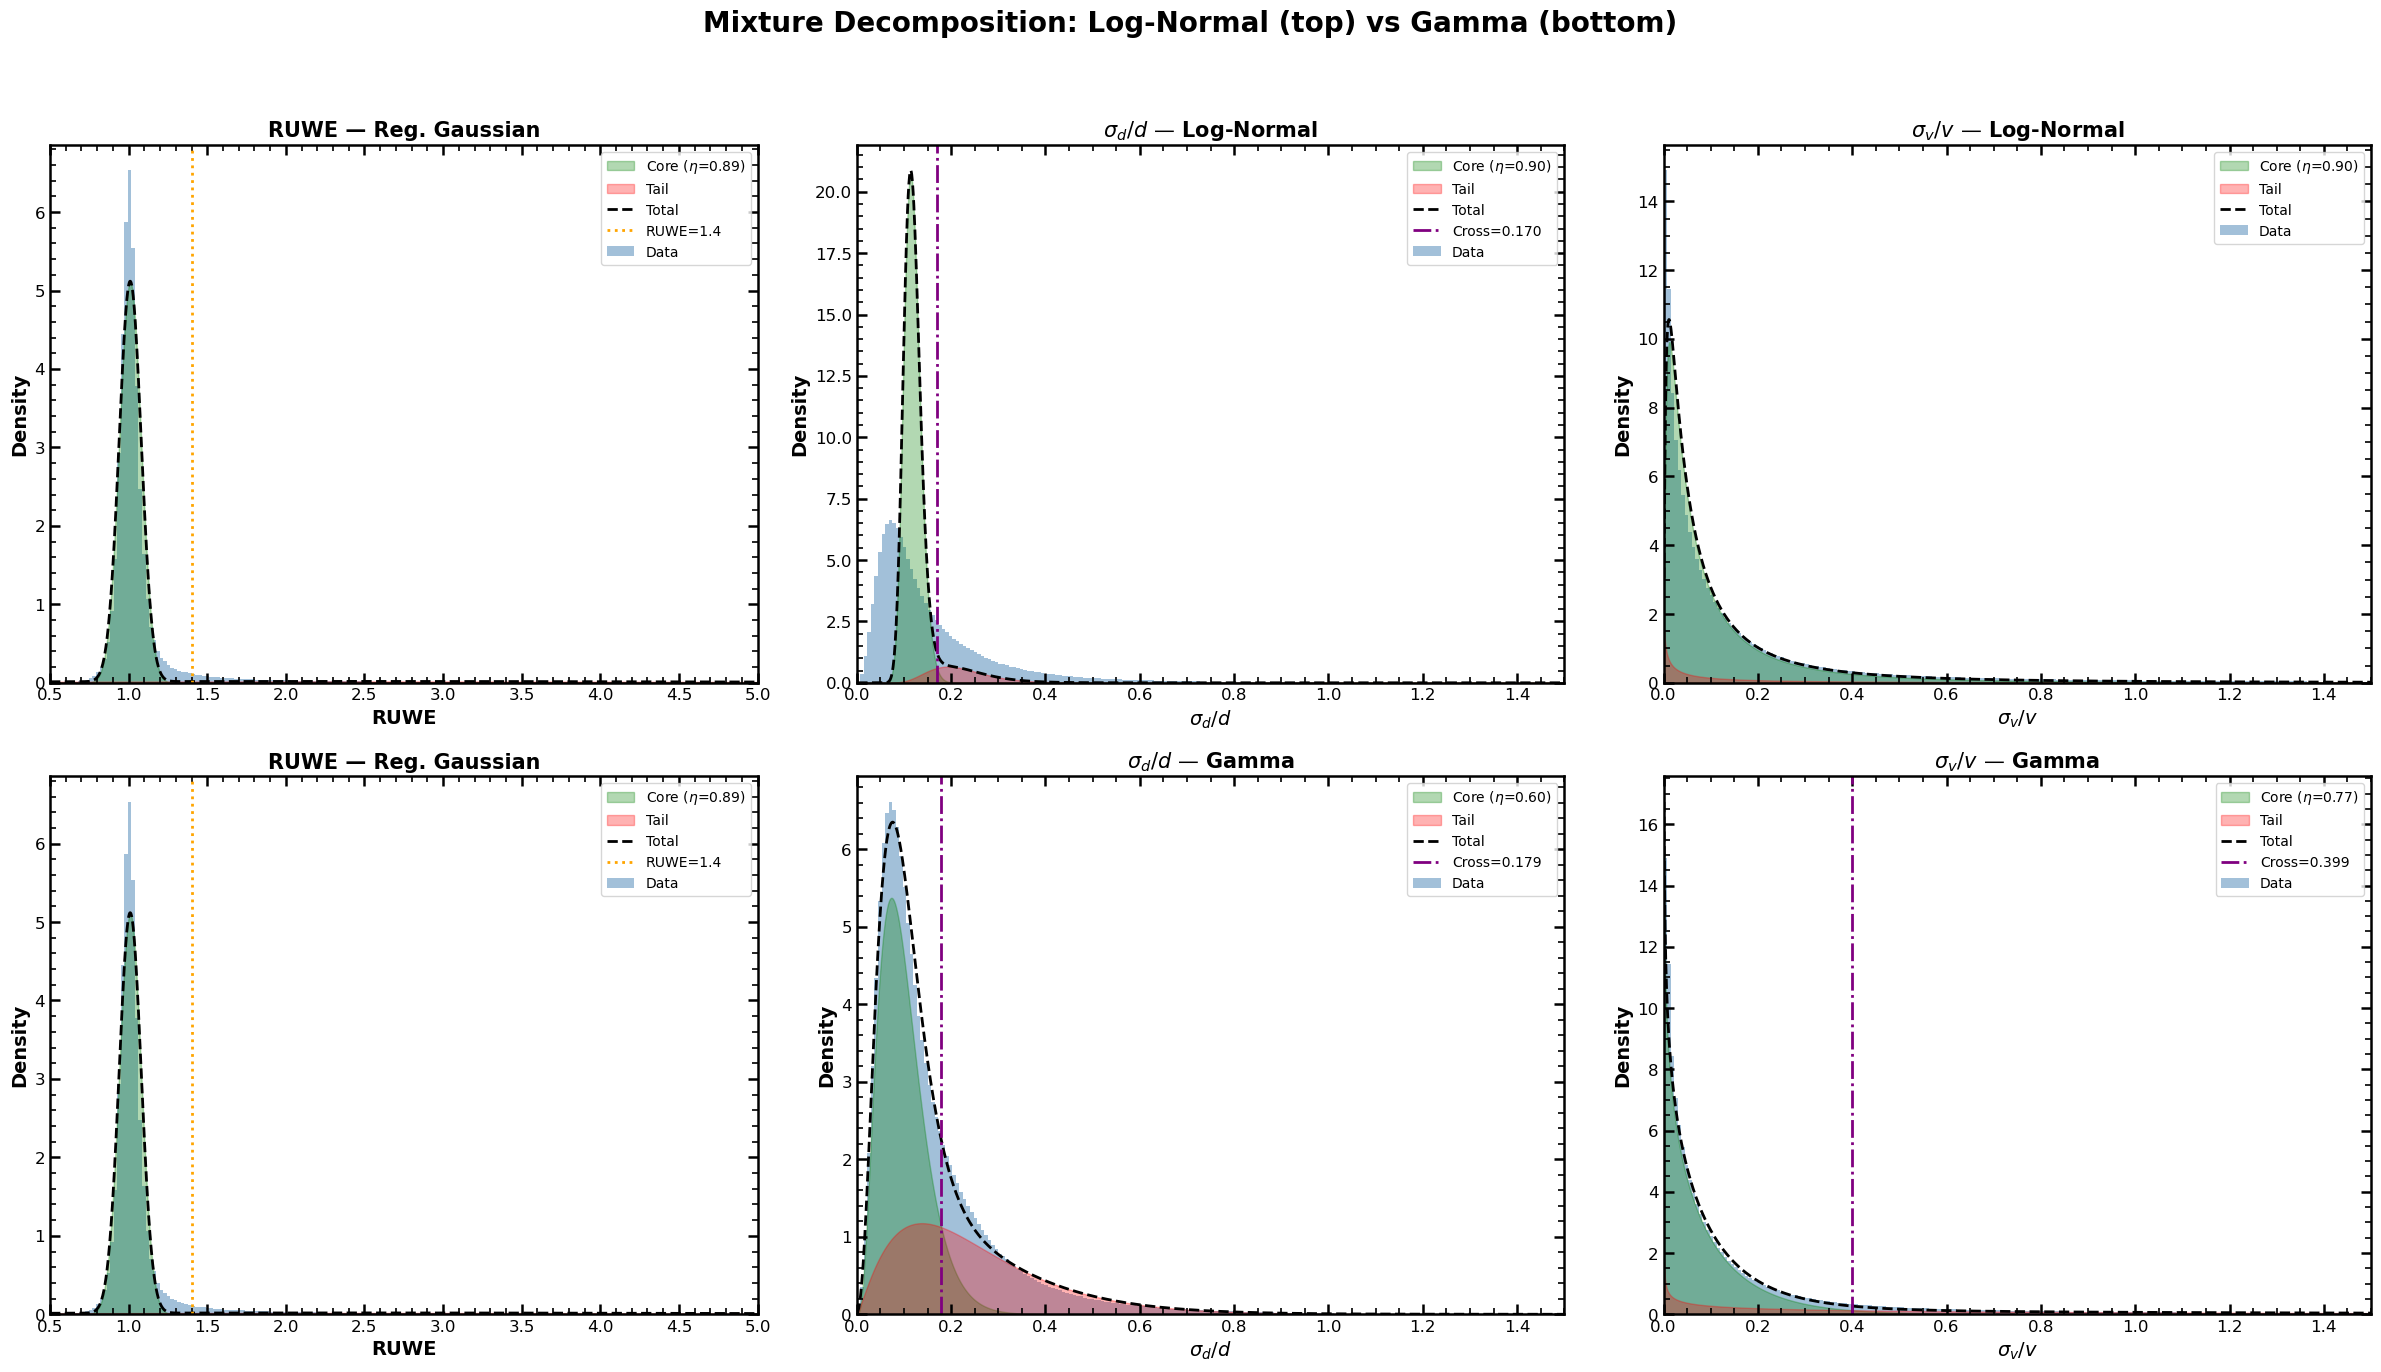

In [30]:
fig, axes = plt.subplots(2, 3, figsize=(24, 14))
fig.suptitle('Mixture Decomposition: Log-Normal (top) vs Gamma (bottom)',
             fontsize=20, fontweight='bold', y=0.98)

x_ruwe = np.linspace(0.5, 5.0, 2000)
x_err  = np.linspace(0.001, 1.5, 2000)

def plot_hist(ax, col, xlim):
    if 'metric_histograms' in EX and col in EX['metric_histograms']:
        h = EX['metric_histograms'][col]
        edges  = np.array(h['edges'])
        counts = np.array(h['counts'])
        centers = 0.5*(edges[:-1]+edges[1:])
        ax.bar(centers, counts, width=np.diff(edges), alpha=0.5,
               color='steelblue', label='Data', align='center')

# ── helper: draw one mixture panel ───────────────────────────
def mix_panel(ax, x, core_fn, tail_fn, params, hist_col, xlim,
              xlabel, title, vline=None, vline_label=None,
              show_cross=False):
    plot_hist(ax, hist_col, xlim)
    cy = core_fn(x, params)
    ty = tail_fn(x, params)
    ax.fill_between(x, cy, alpha=0.3, color='green',
                    label=f'Core ($\\eta$={params["eta"]:.2f})')
    ax.fill_between(x, ty, alpha=0.3, color='red', label='Tail')
    ax.plot(x, cy+ty, 'k--', lw=2, label='Total')
    if show_cross:
        cx = crossover(x, cy, ty)
        if cx is not None:
            ax.axvline(cx, color='purple', ls='-.', lw=2, label=f'Cross={cx:.3f}')
    if vline is not None:
        ax.axvline(vline, color='orange', ls=':', lw=2, label=vline_label)
    ax.set_xlabel(xlabel); ax.set_ylabel('Density')
    ax.set_title(title); ax.set_xlim(xlim)
    ax.legend(loc='upper right'); style_ax(ax)

# Row 0: Gaussian RUWE | LN dist | LN rv
for row in range(2):
    ax = axes[row, 0]
    if 'ruwe' in models:
        mix_panel(ax, x_ruwe, ga_core, ga_tail, models['ruwe'],
                  'ruwe', (0.5, 5.0), 'RUWE',
                  'RUWE — Reg. Gaussian',
                  vline=1.4, vline_label='RUWE=1.4')

if 'dist_ln' in models:
    mix_panel(axes[0,1], x_err, ln_core, ln_tail, models['dist_ln'],
              'rel_dist_err', (0.0, 1.5), r'$\sigma_d/d$',
              r'$\sigma_d/d$ — Log-Normal', show_cross=True)

if 'rv_ln' in models:
    mix_panel(axes[0,2], x_err, ln_core, ln_tail, models['rv_ln'],
              'rel_rv_err', (0.0, 1.5), r'$\sigma_v/v$',
              r'$\sigma_v/v$ — Log-Normal', show_cross=True)

if 'dist_gm' in models:
    mix_panel(axes[1,1], x_err, gm_core, gm_tail, models['dist_gm'],
              'rel_dist_err', (0.0, 1.5), r'$\sigma_d/d$',
              r'$\sigma_d/d$ — Gamma', show_cross=True)

if 'rv_gm' in models:
    mix_panel(axes[1,2], x_err, gm_core, gm_tail, models['rv_gm'],
              'rel_rv_err', (0.0, 1.5), r'$\sigma_v/v$',
              r'$\sigma_v/v$ — Gamma', show_cross=True)

plt.tight_layout(rect=[0, 0, 1, 0.95])
savefig(fig, 'plot1_mixture_comparison.png')

## Plot 2 — Purity Curves (left) + Purity Distributions (right)

  Saved: /user/sutirtha/BallTree_Xmatch/rigorous_comp_purity_results1/plots_rerun/plot2_purity_curves_and_distributions.png


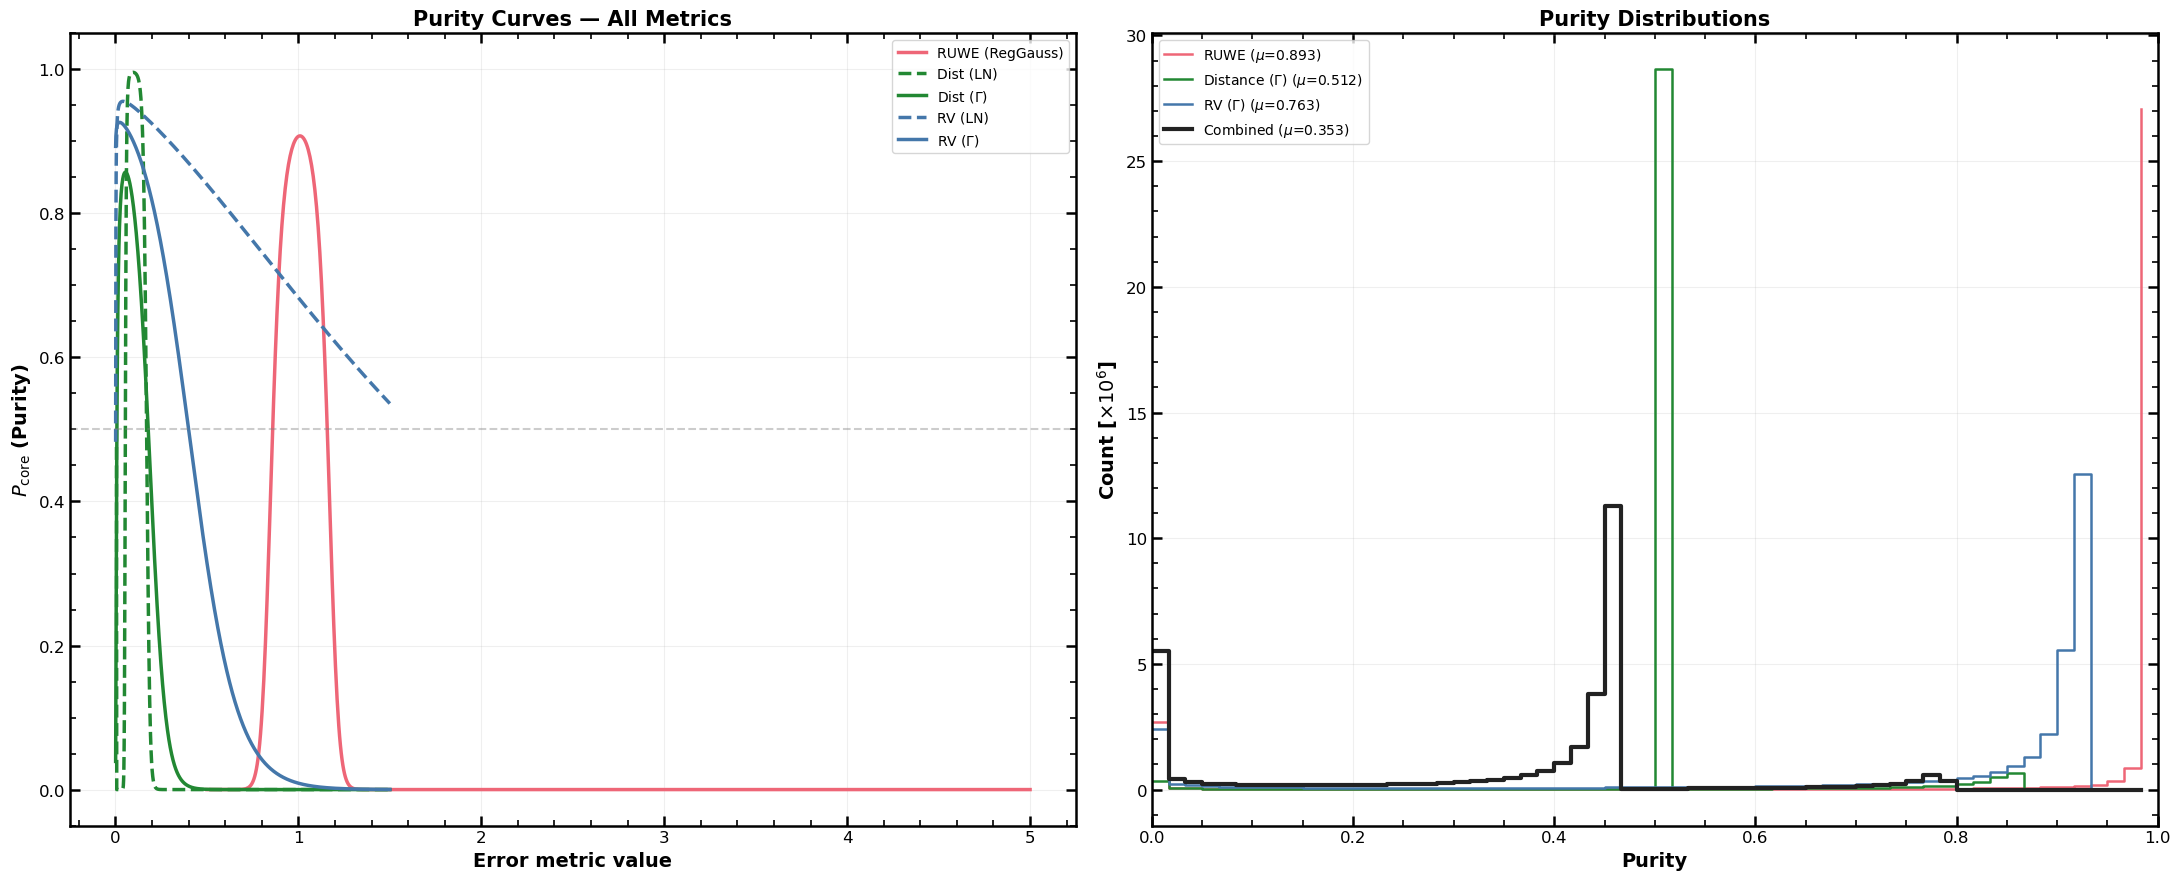

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(22, 9))

# ── LEFT: P_core(x) curves ───────────────────────────────────
ax = axes[0]
x_ruwe = np.linspace(0.5, 5.0, 1000)
x_err  = np.linspace(0.001, 1.5, 1000)

if 'ruwe' in models:
    ax.plot(x_ruwe, purity_gauss(x_ruwe, models['ruwe']),
            color=COL_RUWE, lw=2.5, ls='-', label='RUWE (RegGauss)')

if 'dist_ln' in models:
    cy = ln_core(x_err, models['dist_ln']); ty = ln_tail(x_err, models['dist_ln'])
    ax.plot(x_err, purity_pdf(cy, ty), color=COL_DIST, ls='--', lw=2.5, label=r'Dist (LN)')
if 'dist_gm' in models:
    cy = gm_core(x_err, models['dist_gm']); ty = gm_tail(x_err, models['dist_gm'])
    ax.plot(x_err, purity_pdf(cy, ty), color=COL_DIST, ls='-',  lw=2.5, label=r'Dist ($\Gamma$)')

if 'rv_ln' in models:
    cy = ln_core(x_err, models['rv_ln']); ty = ln_tail(x_err, models['rv_ln'])
    ax.plot(x_err, purity_pdf(cy, ty), color=COL_RV, ls='--', lw=2.5, label=r'RV (LN)')
if 'rv_gm' in models:
    cy = gm_core(x_err, models['rv_gm']); ty = gm_tail(x_err, models['rv_gm'])
    ax.plot(x_err, purity_pdf(cy, ty), color=COL_RV, ls='-',  lw=2.5, label=r'RV ($\Gamma$)')

ax.axhline(0.5, color='gray', ls='--', alpha=0.4)
ax.set_xlabel('Error metric value')
ax.set_ylabel(r'$P_{\rm core}$ (Purity)')
ax.set_title('Purity Curves — All Metrics')
ax.set_ylim(-0.05, 1.05)
ax.legend(fontsize=10); ax.grid(True, alpha=0.2); style_ax(ax)

# ── RIGHT: purity distributions ──────────────────────────────
ax = axes[1]
ph = EX.get('purity_histograms', {})

col_map = [
    ('purity_ruwe',     COL_RUWE, 'RUWE',                    1.8),
    ('purity_dist',     COL_DIST, r'Distance ($\Gamma$)',     1.8),
    ('purity_rv',       COL_RV,   r'RV ($\Gamma$)',           1.8),
    ('purity_combined', COL_COMB, 'Combined',                 3.0),
]
for col, clr, lab, lw in col_map:
    if col in ph:
        h = ph[col]
        edges  = np.array(h['edges'])
        counts = np.array(h['counts'])
        mu = h['mean']
        ax.step(edges[:-1], counts/1e6, where='post', color=clr, lw=lw,
                label=f'{lab} ($\\mu$={mu:.3f})')
    elif ph:
        print(f'  {col} not in extra_plot_data.json')

ax.set_xlabel('Purity'); ax.set_ylabel(r'Count [$\times 10^6$]')
ax.set_title('Purity Distributions'); ax.set_xlim(0, 1)
ax.legend(fontsize=10); ax.grid(True, alpha=0.2); style_ax(ax)

plt.tight_layout()
savefig(fig, 'plot2_purity_curves_and_distributions.png')

## Plot 3 — Radial Profiles (dist / rv / ruwe)

/tmp/ipykernel_2265621/4147434135.py:86: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


  Saved: /user/sutirtha/BallTree_Xmatch/rigorous_comp_purity_results1/plots_rerun/plot3_radial_dist.png


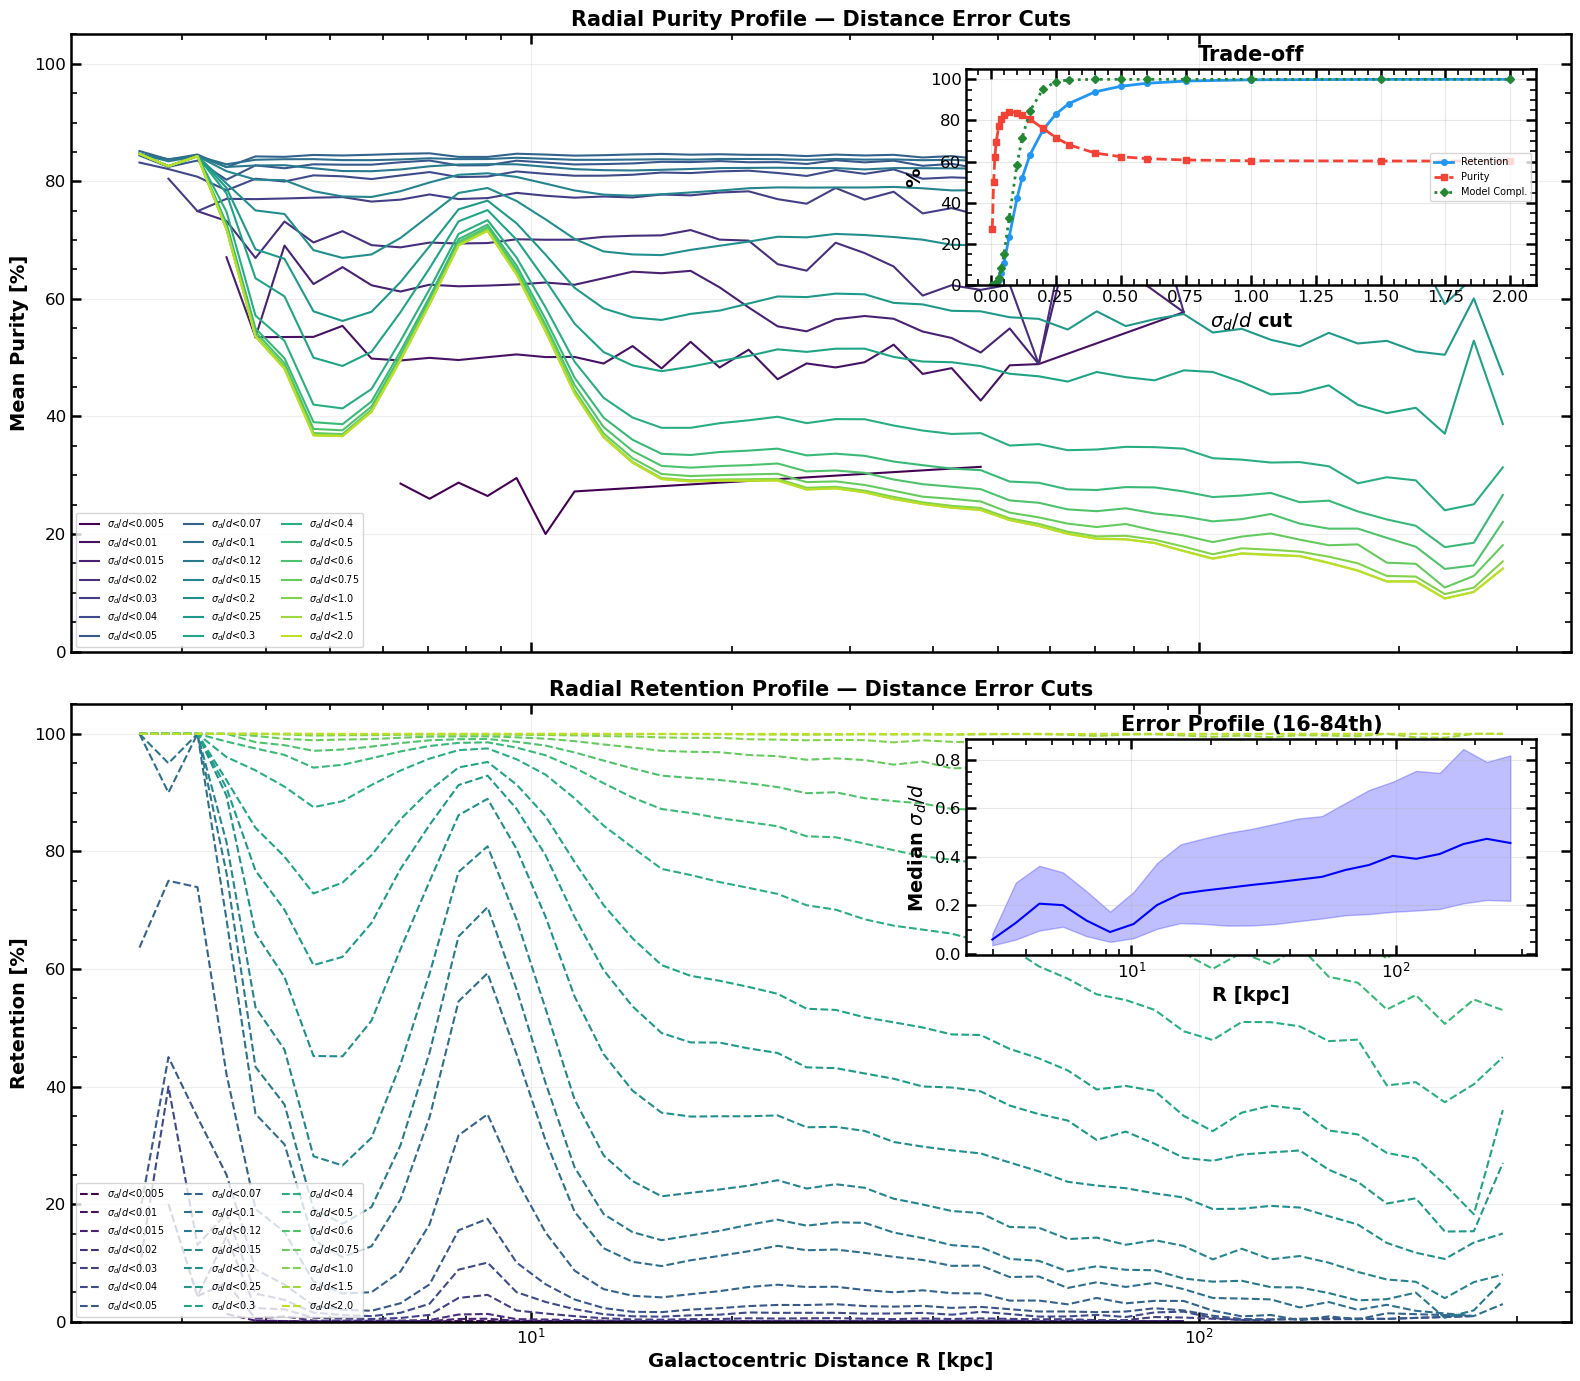

  Saved: /user/sutirtha/BallTree_Xmatch/rigorous_comp_purity_results1/plots_rerun/plot3_radial_rv.png


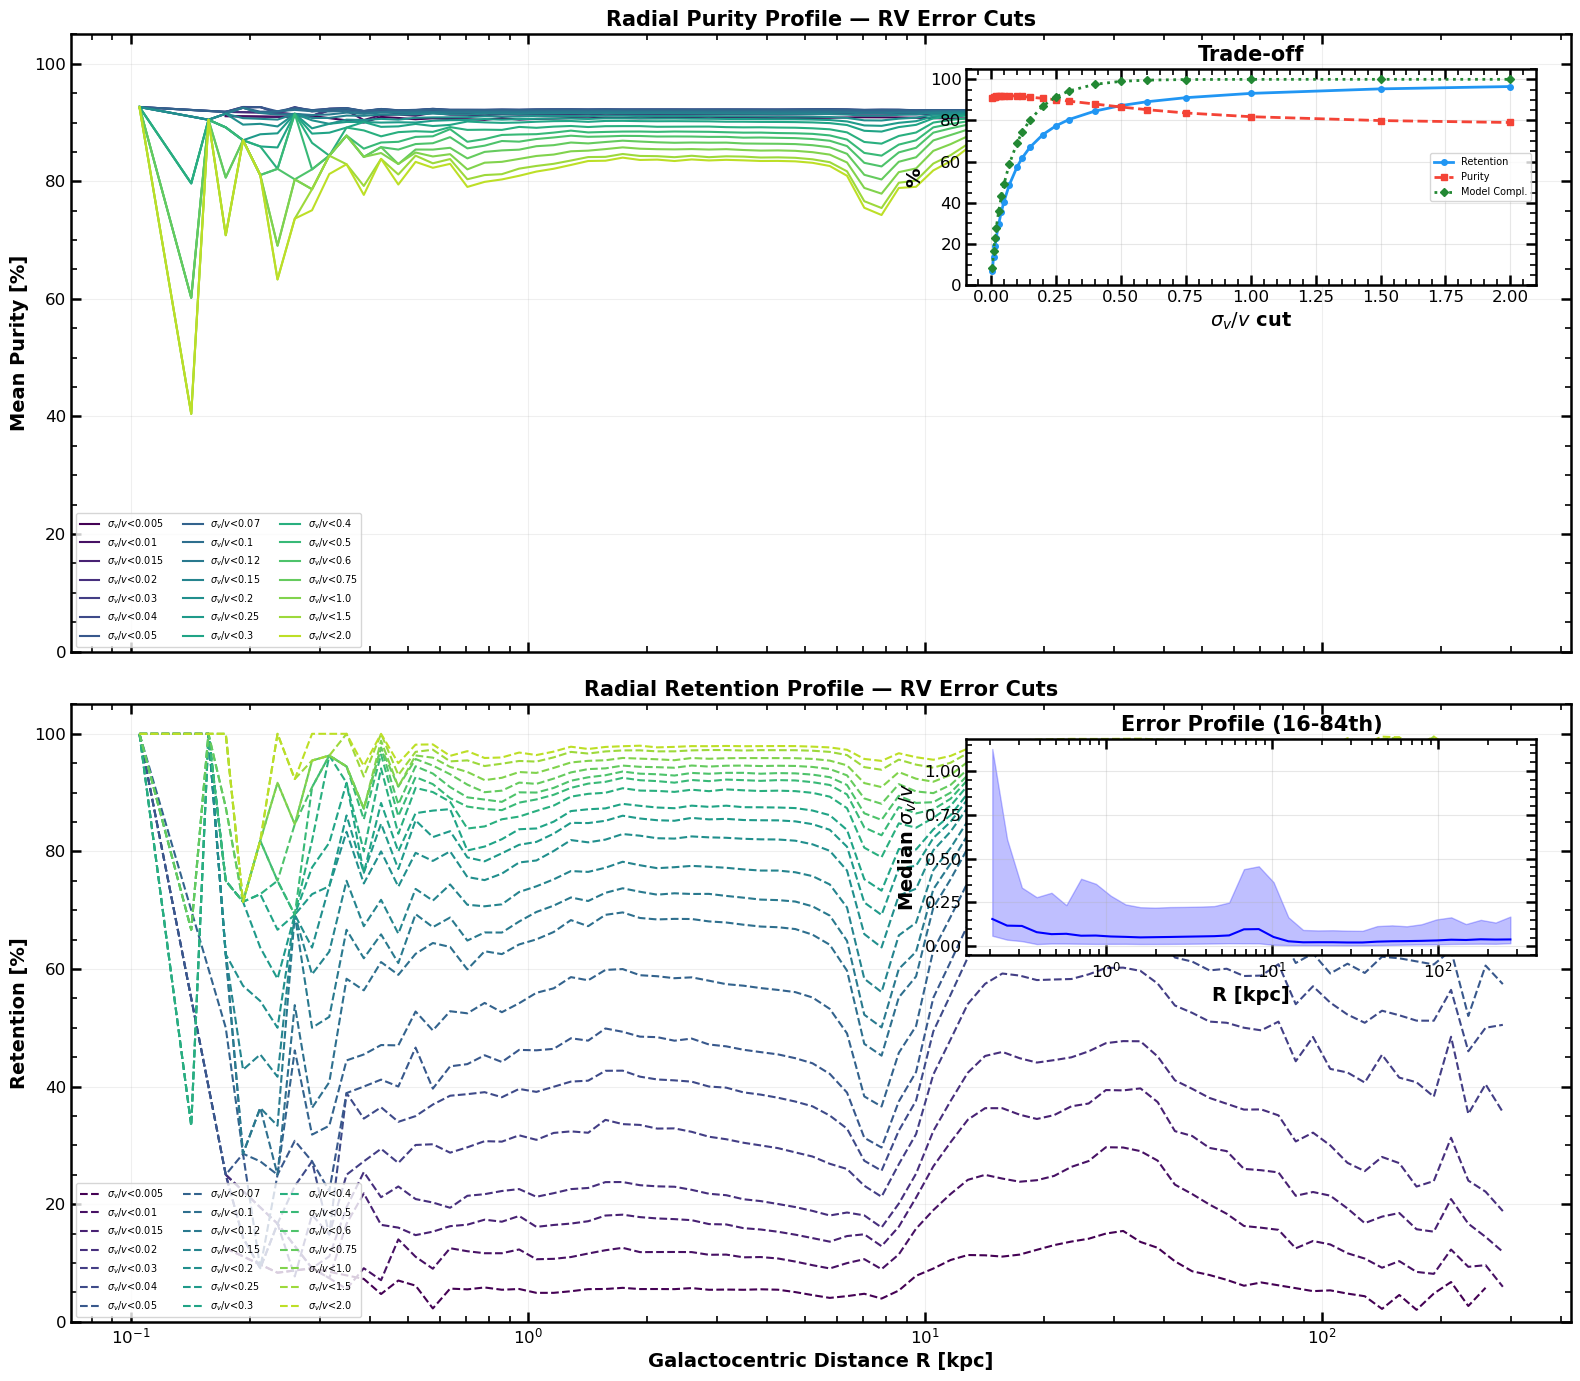

  Saved: /user/sutirtha/BallTree_Xmatch/rigorous_comp_purity_results1/plots_rerun/plot3_radial_ruwe.png


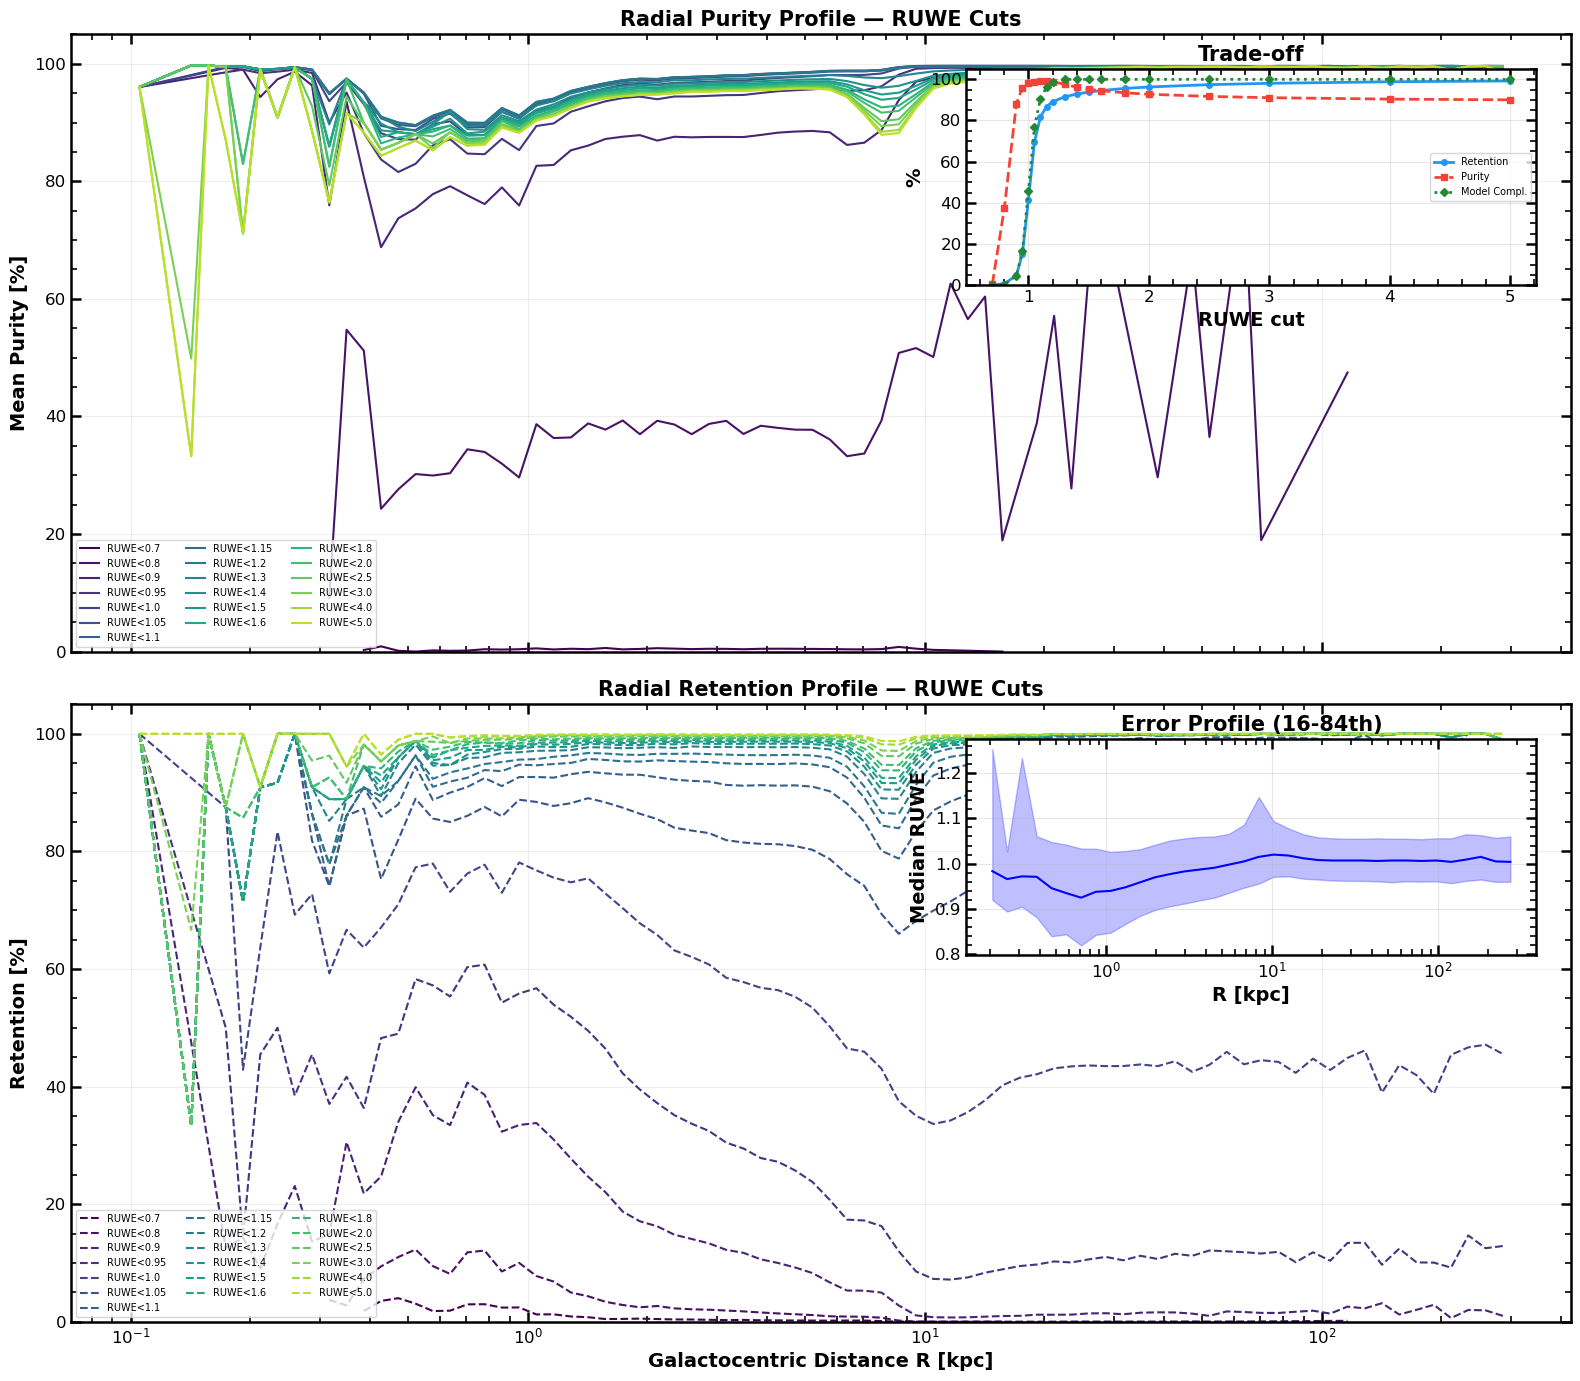

In [32]:
rep = EX.get('radial_error_profiles', {})

for key, mcol, title, xlabel in [
    ('dist', 'rel_dist_err', r'$\sigma_d/d$', 'Distance Error'),
    ('rv',   'rel_rv_err',   r'$\sigma_v/v$', 'RV Error'),
    ('ruwe', 'ruwe',         'RUWE',           'RUWE'),
]:
    rk = key + '_radial'
    gk = key + '_global'
    if rk not in tr or gk not in tr:
        print(f'Skipping {key} — tradeoff data missing'); continue

    fig, (ax_pur, ax_ret) = plt.subplots(2, 1, figsize=(16, 14), sharex=True)
    rd = tr[rk]; gd = tr[gk]
    rc       = np.array(rd['r_centers'])
    bc       = rd['by_cut']
    cut_keys = sorted(bc.keys(), key=float)
    clrs     = plt.cm.viridis(np.linspace(0, 0.9, len(cut_keys)))

    # ── TOP: Radial purity profile ────────────────────────────
    for ck, clr in zip(cut_keys, clrs):
        pp = np.array(bc[ck]['purity']); vm = np.isfinite(pp)
        if np.sum(vm) > 3:
            ax_pur.plot(rc[vm], pp[vm]*100, '-', color=clr, lw=1.5,
                        label=f'{title}<{float(ck)}')
    ax_pur.set_ylabel('Mean Purity [%]')
    ax_pur.set_title(f'Radial Purity Profile — {xlabel} Cuts',
                     fontsize=18, fontweight='bold')
    ax_pur.set_xscale('log'); ax_pur.set_ylim(0, 105)
    ax_pur.grid(True, alpha=0.2)
    ax_pur.legend(loc='lower left', fontsize=7, ncol=3)
    style_ax(ax_pur)

    # Inset: global trade-off
    ax_i1 = inset_axes(ax_pur, width='38%', height='35%', loc='upper right', borderpad=2.5)
    ax_i1.patch.set_facecolor('white'); ax_i1.patch.set_alpha(1.0)
    ax_i1.plot(gd['cuts'], [r*100 for r in gd['retention']],
               'o-', color='#2196F3', lw=2, ms=4, label='Retention')
    ax_i1.plot(gd['cuts'],
               [p*100 if not (p is None or (isinstance(p, float) and np.isnan(p))) else 0
                for p in gd['mean_purity']],
               's--', color='#F44336', lw=2, ms=4, label='Purity')
    ax_i1.plot(gd['cuts'], [c*100 for c in gd['model_completeness']],
               'D:', color='#228833', lw=2, ms=4, label='Model Compl.')
    ax_i1.set_xlabel(f'{title} cut', fontsize=9, fontweight='bold')
    ax_i1.set_ylabel('%', fontsize=9, fontweight='bold')
    ax_i1.set_title('Trade-off', fontsize=10, fontweight='bold')
    ax_i1.set_ylim(0, 105); ax_i1.legend(fontsize=7, loc='center right')
    ax_i1.grid(True, alpha=0.3); style_ax(ax_i1)

    # ── BOTTOM: Radial retention profile ─────────────────────
    for ck, clr in zip(cut_keys, clrs):
        rr = np.array(bc[ck]['retention']); vm = np.isfinite(rr)
        if np.sum(vm) > 3:
            ax_ret.plot(rc[vm], rr[vm]*100, '--', color=clr, lw=1.5,
                        label=f'{title}<{float(ck)}')
    ax_ret.set_xlabel('Galactocentric Distance R [kpc]')
    ax_ret.set_ylabel('Retention [%]')
    ax_ret.set_title(f'Radial Retention Profile — {xlabel} Cuts',
                     fontsize=18, fontweight='bold')
    ax_ret.set_xscale('log'); ax_ret.set_ylim(0, 105)
    ax_ret.grid(True, alpha=0.2)
    ax_ret.legend(loc='lower left', fontsize=7, ncol=3)
    style_ax(ax_ret)

    # Inset: radial error profile (16-84th percentile)
    ax_i2 = inset_axes(ax_ret, width='38%', height='35%', loc='upper right', borderpad=2.5)
    ax_i2.patch.set_facecolor('white'); ax_i2.patch.set_alpha(1.0)
    if mcol in rep:
        rp   = rep[mcol]
        rcm2 = np.array(rp['r_centers'], dtype=float)
        meds = np.array([v if v is not None else np.nan for v in rp['median']])
        p16s = np.array([v if v is not None else np.nan for v in rp['p16']])
        p84s = np.array([v if v is not None else np.nan for v in rp['p84']])
        vm2  = np.isfinite(meds)
        if np.sum(vm2) > 2:
            ax_i2.plot(rcm2[vm2], meds[vm2], 'b-', lw=1.5)
            ax_i2.fill_between(rcm2[vm2], p16s[vm2], p84s[vm2], alpha=0.25, color='blue')
        ax_i2.set_xscale('log')
        ax_i2.set_xlabel('R [kpc]', fontsize=9, fontweight='bold')
        ax_i2.set_ylabel(f'Median {title}', fontsize=9, fontweight='bold')
        ax_i2.set_title('Error Profile (16-84th)', fontsize=10, fontweight='bold')
        ax_i2.grid(True, alpha=0.3)
    style_ax(ax_i2)

    plt.tight_layout()
    savefig(fig, f'plot3_radial_{key}.png')

## Plot 4 — Core Fraction η

  Saved: /user/sutirtha/BallTree_Xmatch/rigorous_comp_purity_results1/plots_rerun/plot4_core_fraction_eta.png


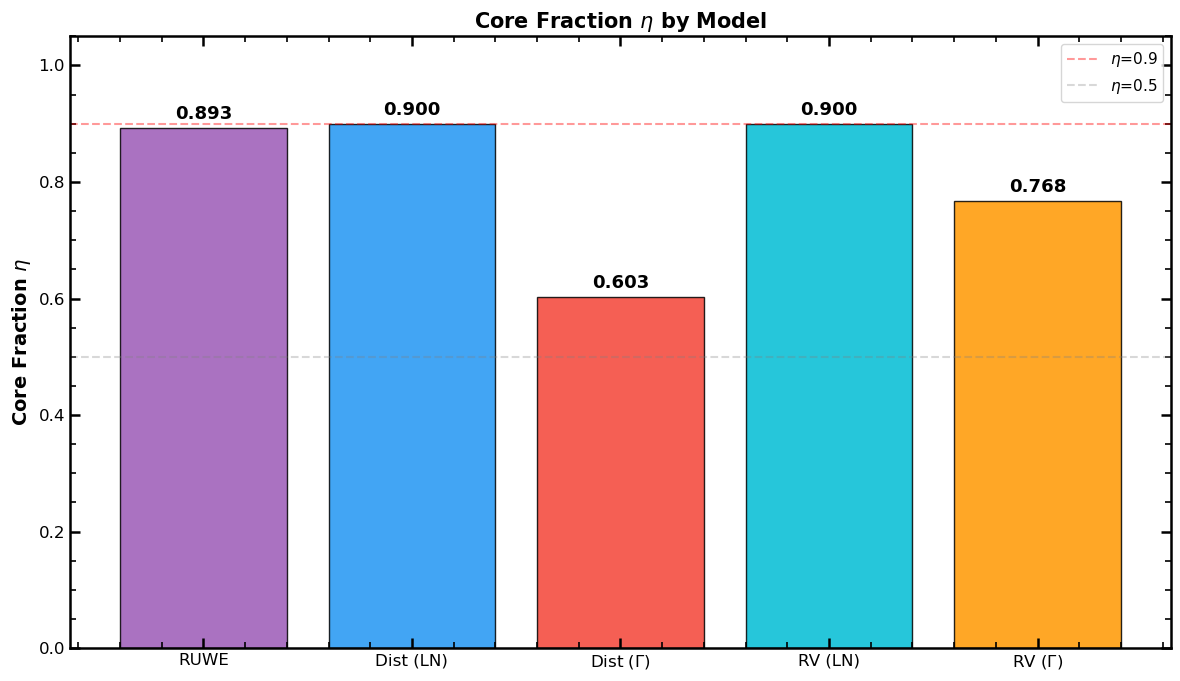

In [33]:
fig, ax = plt.subplots(figsize=(12, 7))
labels, vals, clrs = [], [], []
if 'ruwe' in pr:
    labels.append('RUWE');             vals.append(pr['ruwe'].get('eta', 0));               clrs.append('#9b59b6')
if 'dist' in pr:
    labels.append('Dist (LN)');        vals.append(pr['dist']['lognormal'].get('eta', 0));  clrs.append('#2196F3')
    labels.append(r'Dist ($\Gamma$)'); vals.append(pr['dist']['gamma'].get('eta', 0));      clrs.append('#F44336')
if 'rv' in pr:
    labels.append('RV (LN)');          vals.append(pr['rv']['lognormal'].get('eta', 0));    clrs.append('#00BCD4')
    labels.append(r'RV ($\Gamma$)');   vals.append(pr['rv']['gamma'].get('eta', 0));        clrs.append('#FF9800')

bars = ax.bar(labels, vals, color=clrs, edgecolor='black', alpha=0.85)
for b, v in zip(bars, vals):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.015, f'{v:.3f}',
            ha='center', fontsize=13, fontweight='bold')
ax.set_ylim(0, 1.05)
ax.axhline(0.9, color='red',  ls='--', alpha=0.4, label=r'$\eta$=0.9')
ax.axhline(0.5, color='gray', ls='--', alpha=0.3, label=r'$\eta$=0.5')
ax.set_ylabel(r'Core Fraction $\eta$')
ax.set_title(r'Core Fraction $\eta$ by Model', fontsize=18, fontweight='bold')
ax.legend(fontsize=11); style_ax(ax)
plt.tight_layout()
savefig(fig, 'plot4_core_fraction_eta.png')

## Plot 5 — Mean Purity by Method

  Saved: /user/sutirtha/BallTree_Xmatch/rigorous_comp_purity_results1/plots_rerun/plot5_purity_by_method.png


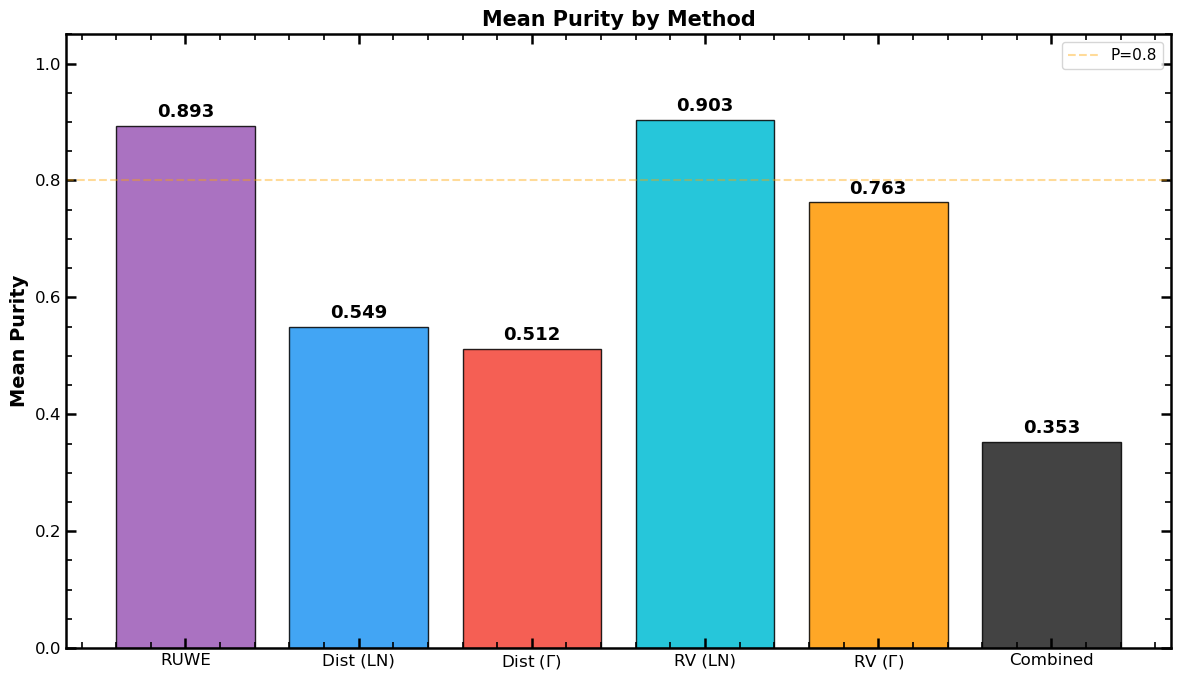

In [34]:
fig, ax = plt.subplots(figsize=(12, 7))
labels, vals, clrs = [], [], []
if 'ruwe' in pr:
    labels.append('RUWE');             vals.append(pr['ruwe'].get('mean_purity', 0));       clrs.append('#9b59b6')
if 'dist' in pr:
    labels.append('Dist (LN)');        vals.append(pr['dist'].get('mean_purity_ln', 0));    clrs.append('#2196F3')
    labels.append(r'Dist ($\Gamma$)'); vals.append(pr['dist'].get('mean_purity_gm', 0));    clrs.append('#F44336')
if 'rv' in pr:
    labels.append('RV (LN)');          vals.append(pr['rv'].get('mean_purity_ln', 0));      clrs.append('#00BCD4')
    labels.append(r'RV ($\Gamma$)');   vals.append(pr['rv'].get('mean_purity_gm', 0));      clrs.append('#FF9800')
if 'combined' in pr:
    labels.append('Combined');         vals.append(pr['combined'].get('mean', 0));           clrs.append('#222222')

bars = ax.bar(labels, vals, color=clrs, edgecolor='black', alpha=0.85)
for b, v in zip(bars, vals):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.015, f'{v:.3f}',
            ha='center', fontsize=13, fontweight='bold')
ax.set_ylim(0, 1.05)
ax.axhline(0.8, color='orange', ls='--', alpha=0.4, label='P=0.8')
ax.set_ylabel('Mean Purity')
ax.set_title('Mean Purity by Method', fontsize=18, fontweight='bold')
ax.legend(fontsize=11); style_ax(ax)
plt.tight_layout()
savefig(fig, 'plot5_purity_by_method.png')

## Plot 6 — GC/OC/SGR Truth Completeness (Eq. 22)

  Saved: /user/sutirtha/BallTree_Xmatch/rigorous_comp_purity_results1/plots_rerun/plot6_gc_oc_sgr_completeness.png


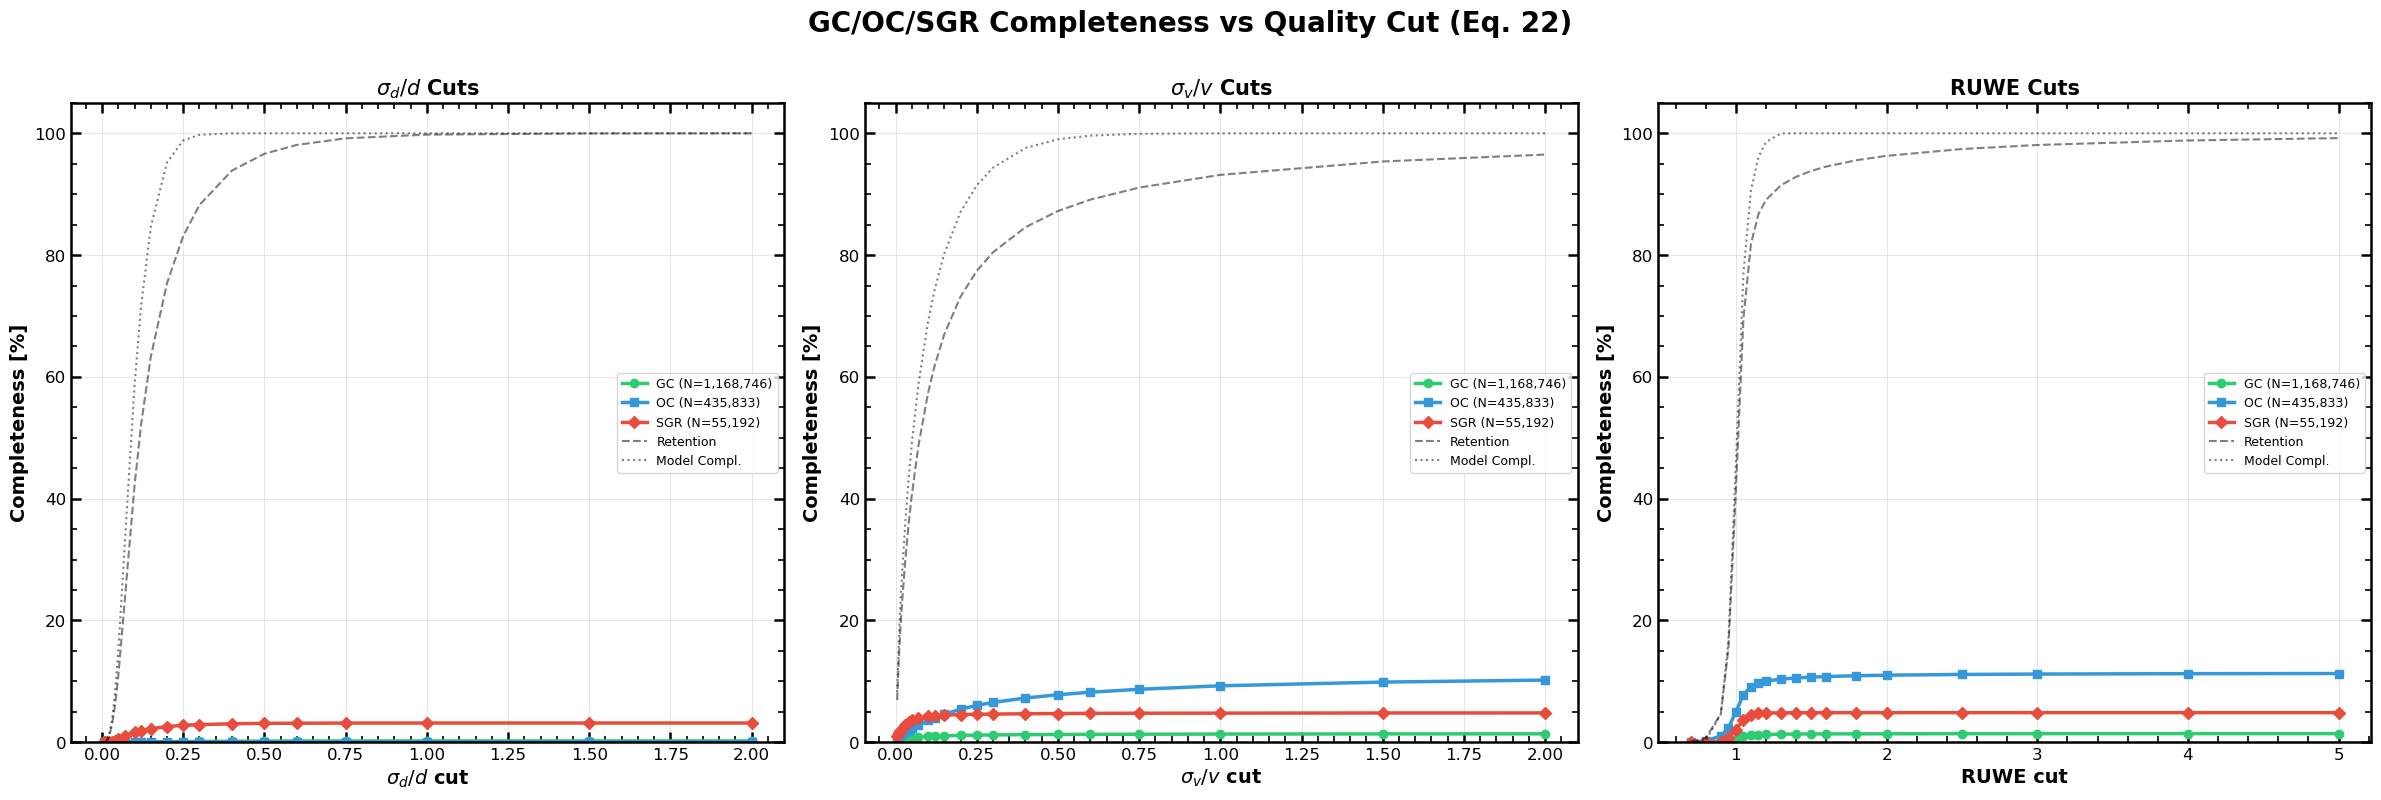

In [35]:
truth_colors  = {'GC': '#2ecc71', 'OC': '#3498db', 'SGR': '#e74c3c'}
truth_markers = {'GC': 'o',       'OC': 's',       'SGR': 'D'}

has_truth = any(
    f'truth_completeness_{lab}' in tr.get(gk, {})
    for gk  in ['dist_global', 'rv_global', 'ruwe_global']
    for lab in ['GC', 'OC', 'SGR']
)

if not has_truth:
    print('No truth completeness data found — skipping Plot 6.')
else:
    fig, axes = plt.subplots(1, 3, figsize=(24, 8))
    fig.suptitle('GC/OC/SGR Completeness vs Quality Cut (Eq. 22)',
                 fontsize=20, fontweight='bold', y=1.0)

    for axi, (gk, title, xlabel) in enumerate([
        ('dist_global',  r'$\sigma_d/d$', r'$\sigma_d/d$ cut'),
        ('rv_global',    r'$\sigma_v/v$', r'$\sigma_v/v$ cut'),
        ('ruwe_global',  'RUWE',          'RUWE cut'),
    ]):
        ax = axes[axi]
        if gk not in tr:
            ax.text(0.5, 0.5, 'No data', ha='center', va='center',
                    transform=ax.transAxes)
            style_ax(ax); continue
        d = tr[gk]
        for lab in ['GC', 'OC', 'SGR']:
            tk = f'truth_completeness_{lab}'
            if tk in d:
                n_tot = truth_meta.get(lab, {}).get('n_total', '?')
                lbl   = f'{lab} (N={n_tot:,})' if isinstance(n_tot, int) else lab
                ax.plot(d['cuts'], [c*100 for c in d[tk]],
                        f'{truth_markers[lab]}-',
                        color=truth_colors[lab], lw=2.5, ms=6, label=lbl)
        ax.plot(d['cuts'], [r*100 for r in d['retention']],
                'k--', lw=1.5, alpha=0.5, label='Retention')
        ax.plot(d['cuts'], [c*100 for c in d['model_completeness']],
                'k:',  lw=1.5, alpha=0.5, label='Model Compl.')
        ax.set_xlabel(xlabel); ax.set_ylabel('Completeness [%]')
        ax.set_title(f'{title} Cuts', fontsize=16, fontweight='bold')
        ax.set_ylim(0, 105); ax.grid(True, alpha=0.3); ax.legend(fontsize=9)
        style_ax(ax)

    plt.tight_layout()
    savefig(fig, 'plot6_gc_oc_sgr_completeness.png')

## Model Parameter Table

In [36]:
import pandas as pd
rows = []
for name, p in models.items():
    row = {'model': name}
    row.update({k: round(v, 4) if isinstance(v, float) else v for k, v in p.items()})
    rows.append(row)
df_params = pd.DataFrame(rows).set_index('model')
display(df_params)

,eta,mu_core,sigma_core,mu_tail,sigma_tail,median_core,median_tail,data_robust_std,alpha_core,beta_core,alpha_tail,beta_tail,mean_core,mean_tail
model,,,,,,,,,,,,,,
ruwe,0.8934,1.0098,0.0698,2.3748,2.4222,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
dist_ln,0.9000,-2.1472,0.1500,-1.5555,0.3000,0.1168,0.2111,0.7397,NaN,NaN,NaN,NaN,NaN,NaN
dist_gm,0.6030,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.8535,38.8596,2.2010,8.7128,0.0992,0.2526
rv_ln,0.9000,-2.7425,1.2863,-1.4091,2.5725,0.0644,0.2444,1.6667,NaN,NaN,NaN,NaN,NaN,NaN
rv_gm,0.7680,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.7977,8.7905,0.6098,0.6436,0.0908,0.9476
